# Network Centrality Analysis

Calculates degree, betweenness, and eigenvector centrality for both drug-level and class-level DDI networks.

**Centrality measures explained:**
- **Degree centrality**: How many other drugs/classes a node is directly connected to. High degree = interaction *hub* (commonly co-prescribed).
- **Betweenness centrality**: How often a node lies on the shortest path between other pairs. High betweenness = *bridge* between therapeutic clusters.
- **Eigenvector centrality**: How well-connected a node is to other well-connected nodes. High eigenvector = drug connects to other *high-risk* drugs.

**Hypotheses (per Professor Lee):**
- Common drugs (acetaminophen, etc.) → high degree (hubs)
- Drugs bridging therapeutic clusters → high betweenness
- Immunosuppressants → high eigenvector (connect to other high-risk drugs)

## Prerequisites

**Inputs (from notebooks 11 and 12):**
- `../network/gephi_nodes.csv` (682 drugs)
- `../network/gephi_edges.csv` (5,501 drug-drug edges)
- `../network/gephi_class_network_nodes.csv` (26 ATC classes)
- `../network/gephi_class_network_edges.csv` (74 class-class edges)

**Outputs:**
- `../results/FAERS_DRUG_CENTRALITY.csv` — full centrality scores for all 682 drugs
- `../results/FAERS_CLASS_CENTRALITY.csv` — centrality scores for all 26 classes
- `../results/TABLE_top20_centrality_*.csv` — top-20 tables (3 measures × 2 levels = 6 tables)
- `../figures/thesis/fig_centrality_top20.png` — combined top-20 figure
- `../figures/thesis/fig_centrality_network.png` — drug-level network with nodes sized by centrality

Self-contained: loads from CSVs, no kernel state needed.

In [1]:
# ============================================================
# IMPORTS AND DATA LOADING
# ============================================================
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

print("=" * 60)
print("LOADING NETWORK DATA")
print("=" * 60)

# Drug-level network
nodes_drug = pd.read_csv("../network/gephi_nodes.csv")
edges_drug = pd.read_csv("../network/gephi_edges.csv")
print(f"Drug-level: {len(nodes_drug):,} nodes, {len(edges_drug):,} edges")

# Class-level network
nodes_class = pd.read_csv("../network/gephi_class_network_nodes.csv")
edges_class = pd.read_csv("../network/gephi_class_network_edges.csv")
print(f"Class-level: {len(nodes_class):,} nodes, {len(edges_class):,} edges")

LOADING NETWORK DATA
Drug-level: 682 nodes, 5,501 edges
Class-level: 26 nodes, 74 edges


## 1. Build NetworkX Graphs

Both networks are undirected weighted graphs. Edge weights = ROR (drug-level) or DDI count weight (class-level).

Drug-level graph may have small disconnected components (drugs with very few interactions). For eigenvector centrality, we use the largest connected component.

In [2]:
# Drug-level NetworkX graph
G_drug = nx.Graph()
for _, row in nodes_drug.iterrows():
    G_drug.add_node(row['Id'], drug_class=row['drug_class'], signal_count=row['signal_count'])
for _, row in edges_drug.iterrows():
    G_drug.add_edge(row['Source'], row['Target'], weight=row['Weight'], ror=row['ROR'])

print(f"Drug-level network:")
print(f"  Nodes: {G_drug.number_of_nodes():,}")
print(f"  Edges: {G_drug.number_of_edges():,}")
print(f"  Connected: {nx.is_connected(G_drug)}")
components = list(nx.connected_components(G_drug))
print(f"  Connected components: {len(components)}")
print(f"  Largest component: {len(max(components, key=len)):,} nodes")

# Class-level NetworkX graph
G_class = nx.Graph()
for _, row in nodes_class.iterrows():
    G_class.add_node(row['Id'], num_drugs=row['NUM_DRUGS'], freq=row['FREQ'])
for _, row in edges_class.iterrows():
    G_class.add_edge(row['Source'], row['Target'], weight=row['Weight'], avg_ror=row['AVG_ROR'])

print(f"\nClass-level network:")
print(f"  Nodes: {G_class.number_of_nodes()}")
print(f"  Edges: {G_class.number_of_edges()}")
print(f"  Connected: {nx.is_connected(G_class)}")

Drug-level network:
  Nodes: 682
  Edges: 5,501
  Connected: False
  Connected components: 6
  Largest component: 671 nodes

Class-level network:
  Nodes: 26
  Edges: 74
  Connected: True


## 2. Drug-Level Centrality

Compute three centrality measures for all 682 drugs.

Note: betweenness is O(n*m) and may take 30-60 seconds for 682 nodes / 5,501 edges.

In [3]:
print("Computing drug-level centrality measures...")

# Degree centrality (normalized to [0,1])
print("  Computing degree centrality...")
degree_cent_drug = nx.degree_centrality(G_drug)

# Betweenness centrality (weight matters here — using ROR)
print("  Computing betweenness centrality (this takes 30-60 sec)...")
betweenness_cent_drug = nx.betweenness_centrality(G_drug, weight='weight')

# Eigenvector centrality on largest connected component
print("  Computing eigenvector centrality...")
largest_cc = max(nx.connected_components(G_drug), key=len)
G_cc = G_drug.subgraph(largest_cc).copy()
eigen_cent_cc = nx.eigenvector_centrality(G_cc, weight='weight', max_iter=1000)
# Pad with 0 for nodes not in main component
eigen_cent_drug = {node: eigen_cent_cc.get(node, 0) for node in G_drug.nodes()}

# Build DataFrame
drug_cent_df = pd.DataFrame({
    'drug': list(G_drug.nodes()),
    'degree_centrality': [degree_cent_drug[n] for n in G_drug.nodes()],
    'betweenness_centrality': [betweenness_cent_drug[n] for n in G_drug.nodes()],
    'eigenvector_centrality': [eigen_cent_drug[n] for n in G_drug.nodes()],
    'degree': [G_drug.degree(n) for n in G_drug.nodes()],
    'drug_class': [G_drug.nodes[n].get('drug_class', 'Unknown') for n in G_drug.nodes()],
})

drug_cent_df = drug_cent_df.sort_values('degree_centrality', ascending=False).reset_index(drop=True)
drug_cent_df.to_csv("../results/FAERS_DRUG_CENTRALITY.csv", index=False)
print(f"\nSaved: ../results/FAERS_DRUG_CENTRALITY.csv ({len(drug_cent_df):,} drugs)")

print(f"\nSummary statistics:")
print(drug_cent_df[['degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'degree']].describe().round(4))

Computing drug-level centrality measures...
  Computing degree centrality...
  Computing betweenness centrality (this takes 30-60 sec)...


  Computing eigenvector centrality...

Saved: ../results/FAERS_DRUG_CENTRALITY.csv (682 drugs)

Summary statistics:
       degree_centrality  betweenness_centrality  eigenvector_centrality  \
count           682.0000                682.0000                682.0000   
mean              0.0237                  0.0026                  0.0211   
std               0.0388                  0.0107                  0.0320   
min               0.0015                  0.0000                  0.0000   
25%               0.0018                  0.0000                  0.0018   
50%               0.0081                  0.0000                  0.0069   
75%               0.0279                  0.0011                  0.0235   
max               0.3818                  0.1859                  0.1938   

         degree  
count  682.0000  
mean    16.1320  
std     26.4216  
min      1.0000  
25%      1.2500  
50%      5.5000  
75%     19.0000  
max    260.0000  


In [4]:
# Top 20 by each centrality measure
print("=" * 70)
print("TOP 20 DRUGS BY DEGREE CENTRALITY (Hubs)")
print("=" * 70)
top_degree_drug = drug_cent_df.nlargest(20, 'degree_centrality')[
    ['drug', 'degree', 'degree_centrality', 'drug_class']]
top_degree_drug['degree_centrality'] = top_degree_drug['degree_centrality'].round(4)
print(top_degree_drug.to_string(index=False))
top_degree_drug.to_csv("../results/TABLE_top20_centrality_drug_degree.csv", index=False)

print("\n" + "=" * 70)
print("TOP 20 DRUGS BY BETWEENNESS CENTRALITY (Bridges)")
print("=" * 70)
top_between_drug = drug_cent_df.nlargest(20, 'betweenness_centrality')[
    ['drug', 'degree', 'betweenness_centrality', 'drug_class']]
top_between_drug['betweenness_centrality'] = top_between_drug['betweenness_centrality'].round(4)
print(top_between_drug.to_string(index=False))
top_between_drug.to_csv("../results/TABLE_top20_centrality_drug_betweenness.csv", index=False)

print("\n" + "=" * 70)
print("TOP 20 DRUGS BY EIGENVECTOR CENTRALITY (Connected to Connected)")
print("=" * 70)
top_eigen_drug = drug_cent_df.nlargest(20, 'eigenvector_centrality')[
    ['drug', 'degree', 'eigenvector_centrality', 'drug_class']]
top_eigen_drug['eigenvector_centrality'] = top_eigen_drug['eigenvector_centrality'].round(4)
print(top_eigen_drug.to_string(index=False))
top_eigen_drug.to_csv("../results/TABLE_top20_centrality_drug_eigenvector.csv", index=False)

print("\nSaved 3 top-20 tables to ../results/")

TOP 20 DRUGS BY DEGREE CENTRALITY (Hubs)
                           drug  degree  degree_centrality              drug_class
                  ACETAMINOPHEN     260             0.3818        Analgesic/Opioid
                     FUROSEMIDE     230             0.3377  Cardiovascular (Other)
                   PANTOPRAZOLE     185             0.2717   Alimentary/Metabolism
                     PREDNISONE     153             0.2247          Corticosteroid
             POTASSIUM CHLORIDE     134             0.1968   Alimentary/Metabolism
                        ELIQUIS     131             0.1924          Antithrombotic
                     FOLIC ACID     125             0.1836           Blood (Other)
                         OXYGEN     118             0.1733                 Various
                        ASPIRIN     116             0.1703          Antithrombotic
                CHOLECALCIFEROL     115             0.1689   Alimentary/Metabolism
                    ALLOPURINOL     103       

## 3. Class-Level Centrality

26 nodes, 74 edges — fully connected, fast to compute. Shows which therapeutic classes are the most central in the DDI network.

In [5]:
# Class-level centrality
degree_cent_class = nx.degree_centrality(G_class)
betweenness_cent_class = nx.betweenness_centrality(G_class, weight='weight')

if nx.is_connected(G_class):
    eigen_cent_class = nx.eigenvector_centrality(G_class, weight='weight', max_iter=1000)
else:
    largest_cc = max(nx.connected_components(G_class), key=len)
    G_cc = G_class.subgraph(largest_cc).copy()
    eigen_cc = nx.eigenvector_centrality(G_cc, weight='weight', max_iter=1000)
    eigen_cent_class = {n: eigen_cc.get(n, 0) for n in G_class.nodes()}

class_cent_df = pd.DataFrame({
    'class': list(G_class.nodes()),
    'degree_centrality': [degree_cent_class[n] for n in G_class.nodes()],
    'betweenness_centrality': [betweenness_cent_class[n] for n in G_class.nodes()],
    'eigenvector_centrality': [eigen_cent_class[n] for n in G_class.nodes()],
    'degree': [G_class.degree(n) for n in G_class.nodes()],
    'num_drugs': [G_class.nodes[n].get('num_drugs', 0) for n in G_class.nodes()],
}).sort_values('degree_centrality', ascending=False).reset_index(drop=True)

class_cent_df.to_csv("../results/FAERS_CLASS_CENTRALITY.csv", index=False)
print(f"Saved: ../results/FAERS_CLASS_CENTRALITY.csv ({len(class_cent_df)} classes)")

# Top 20 (or all 26)
print("\n" + "=" * 70)
print("TOP 20 CLASSES BY DEGREE CENTRALITY")
print("=" * 70)
top_degree_class = class_cent_df.nlargest(20, 'degree_centrality')[
    ['class', 'degree', 'degree_centrality', 'num_drugs']]
top_degree_class['degree_centrality'] = top_degree_class['degree_centrality'].round(3)
print(top_degree_class.to_string(index=False))
top_degree_class.to_csv("../results/TABLE_top20_centrality_class_degree.csv", index=False)

print("\n" + "=" * 70)
print("TOP 20 CLASSES BY BETWEENNESS CENTRALITY")
print("=" * 70)
top_between_class = class_cent_df.nlargest(20, 'betweenness_centrality')[
    ['class', 'degree', 'betweenness_centrality', 'num_drugs']]
top_between_class['betweenness_centrality'] = top_between_class['betweenness_centrality'].round(3)
print(top_between_class.to_string(index=False))
top_between_class.to_csv("../results/TABLE_top20_centrality_class_betweenness.csv", index=False)

print("\n" + "=" * 70)
print("TOP 20 CLASSES BY EIGENVECTOR CENTRALITY")
print("=" * 70)
top_eigen_class = class_cent_df.nlargest(20, 'eigenvector_centrality')[
    ['class', 'degree', 'eigenvector_centrality', 'num_drugs']]
top_eigen_class['eigenvector_centrality'] = top_eigen_class['eigenvector_centrality'].round(3)
print(top_eigen_class.to_string(index=False))
top_eigen_class.to_csv("../results/TABLE_top20_centrality_class_eigenvector.csv", index=False)

Saved: ../results/FAERS_CLASS_CENTRALITY.csv (26 classes)

TOP 20 CLASSES BY DEGREE CENTRALITY
                    class  degree  degree_centrality  num_drugs
    Alimentary/Metabolism      15               0.60         14
        Immunosuppressant      13               0.52         27
         Analgesic/Opioid      13               0.52          9
           Corticosteroid      11               0.44          7
           Antineoplastic      11               0.44          8
      Respiratory (Other)      10               0.40          4
Anti-inflammatory (NSAID)       9               0.36          6
  Musculoskeletal (Other)       8               0.32          4
            Antibacterial       7               0.28          8
           Dermatological       7               0.28          2
           RAAS Inhibitor       7               0.28          4
             Psycholeptic       6               0.24          8
            Antiparasitic       5               0.20          2
   Cardio

## 4. Visualization: Top-20 Drugs by Each Centrality Measure

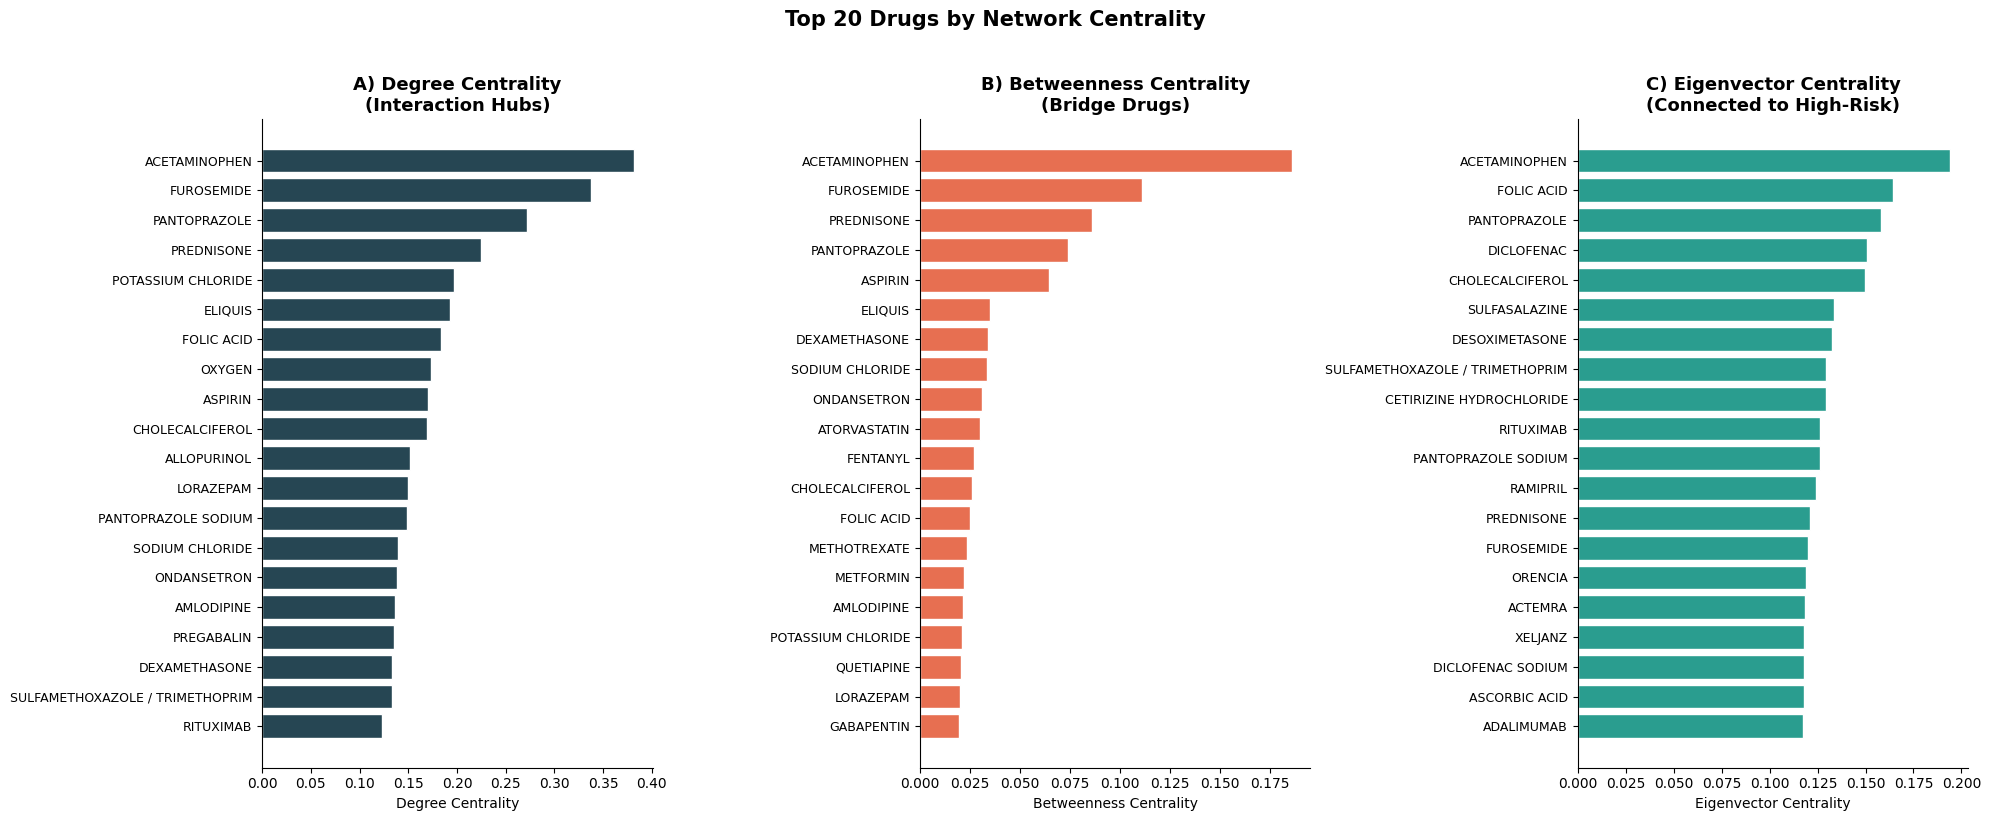

Saved: ../figures/thesis/fig_centrality_top20.png


In [6]:
# Combined figure: 3 panels showing top 20 by each measure
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

panels = [
    ('A) Degree Centrality\n(Interaction Hubs)', drug_cent_df.nlargest(20, 'degree_centrality'),
     'degree_centrality', '#264653'),
    ('B) Betweenness Centrality\n(Bridge Drugs)', drug_cent_df.nlargest(20, 'betweenness_centrality'),
     'betweenness_centrality', '#E76F51'),
    ('C) Eigenvector Centrality\n(Connected to High-Risk)', drug_cent_df.nlargest(20, 'eigenvector_centrality'),
     'eigenvector_centrality', '#2A9D8F'),
]

for ax, (title, data, col, color) in zip(axes, panels):
    data = data.iloc[::-1]  # reverse for top at top
    bars = ax.barh(data['drug'], data[col], color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax, left=False)

plt.suptitle('Top 20 Drugs by Network Centrality',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/thesis/fig_centrality_top20.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ../figures/thesis/fig_centrality_top20.png")

## 5. Network Visualization

Top-50 drugs (by degree) shown with:
- Node size = degree centrality
- Node color = drug class
- Edges scaled by ROR weight

For Gephi visualization, see `../network/gephi_*_top50.csv` files.

Subgraph: 50 nodes, 591 edges


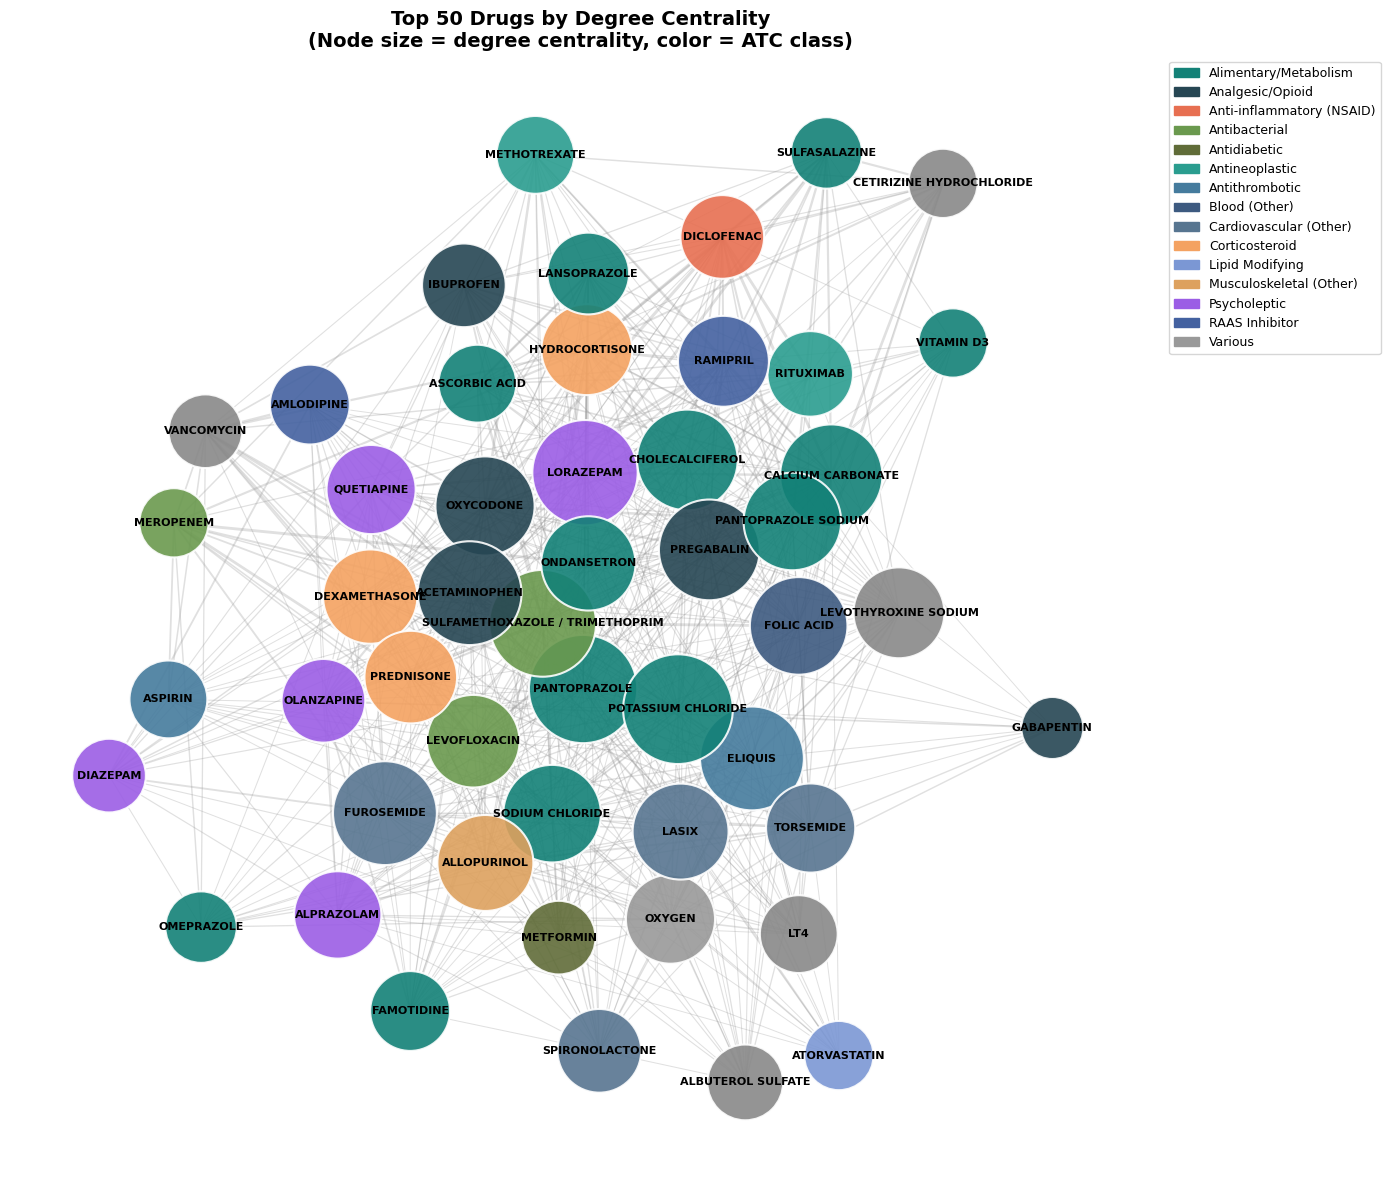

Saved: ../figures/thesis/fig_centrality_network.png


In [7]:
# Get top 50 drugs by degree centrality
top50 = drug_cent_df.nlargest(50, 'degree_centrality')['drug'].tolist()
G_top50 = G_drug.subgraph(top50).copy()
print(f"Subgraph: {G_top50.number_of_nodes()} nodes, {G_top50.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(14, 12))

# Layout
pos = nx.spring_layout(G_top50, seed=42, k=2.5, iterations=100)

# Node sizes by degree centrality (scaled for visibility)
deg_dict = nx.degree_centrality(G_top50)
node_sizes = [deg_dict[n] * 8000 + 200 for n in G_top50.nodes()]

# Color by drug class
class_colors = {
    'Analgesic/Opioid': '#264653',
    'Cardiovascular (Other)': '#577590',
    'Alimentary/Metabolism': '#138177',
    'Corticosteroid': '#F4A261',
    'Immunosuppressant': '#E63946',
    'Antineoplastic': '#2A9D8F',
    'Antithrombotic': '#457B9D',
    'Anti-inflammatory (NSAID)': '#E76F51',
    'Blood (Other)': '#3D5A80',
    'Antibacterial': '#6A994E',
    'Psycholeptic': '#9B5DE5',
    'RAAS Inhibitor': '#4361A0',
    'Lipid Modifying': '#7B97D4',
    'Musculoskeletal (Other)': '#DDA15E',
    'Antidiabetic': '#606C38',
    'Various': '#999999',
}
node_colors = [class_colors.get(G_drug.nodes[n].get('drug_class', 'Various'), '#888888')
               for n in G_top50.nodes()]

# Draw edges (with low alpha)
edge_weights = [d['weight'] for _, _, d in G_top50.edges(data=True)]
if edge_weights:
    max_w = max(edge_weights)
    edge_widths = [w / max_w * 2 + 0.2 for w in edge_weights]
else:
    edge_widths = 0.5

nx.draw_networkx_edges(G_top50, pos, alpha=0.3, width=edge_widths, edge_color='#999999', ax=ax)
nx.draw_networkx_nodes(G_top50, pos, node_size=node_sizes, node_color=node_colors,
                       edgecolors='white', linewidths=1.5, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_top50, pos, font_size=8, font_weight='bold', ax=ax)

# Legend for drug classes
used_classes = set(G_drug.nodes[n].get('drug_class', 'Various') for n in G_top50.nodes())
legend_handles = [mpatches.Patch(color=class_colors.get(c, '#888888'), label=c)
                  for c in sorted(used_classes) if c in class_colors]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize=9, frameon=True)

ax.set_title('Top 50 Drugs by Degree Centrality\n'
             '(Node size = degree centrality, color = ATC class)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/thesis/fig_centrality_network.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ../figures/thesis/fig_centrality_network.png")

## 6. Summary and Interpretation

### Drug-level findings

**Hubs (top degree)**: ACETAMINOPHEN, FUROSEMIDE, PANTOPRAZOLE, PREDNISONE — exactly the commonly co-prescribed drugs we'd expect. These are the drugs that interact with the most other drugs in the dataset.

**Bridges (top betweenness)**: ACETAMINOPHEN, FUROSEMIDE, PREDNISONE, ASPIRIN — drugs that bridge between different therapeutic clusters. These are common across many indications.

**Connected to high-risk (top eigenvector)**: ACETAMINOPHEN, FOLIC ACID, PANTOPRAZOLE, plus immunosuppressants ORENCIA, ACTEMRA, XELJANZ, ADALIMUMAB. The presence of biologics in the top eigenvector list confirms Wayne's hypothesis that immunosuppressants connect to other high-risk drugs.

### Class-level findings

**Top degree class**: Alimentary/Metabolism (PPIs, vitamins) — co-prescribed with everything.

**Top eigenvector class**: Immunosuppressant — confirming Wayne's hypothesis that this class is the most connected to other high-risk classes at the network level.

### Implications for the paper

- Network science adds dimensionality beyond simple signal counts
- High-degree drugs are *not* necessarily high-risk — they're commonly prescribed
- Eigenvector centrality identifies *true* high-risk hubs (immunosuppressants)
- Bridge drugs (high betweenness) are candidates for monitoring across multiple therapeutic clusters

### Output files

**CSVs in `../results/`:**
- `FAERS_DRUG_CENTRALITY.csv` (682 rows, all drugs)
- `FAERS_CLASS_CENTRALITY.csv` (26 rows, all classes)
- `TABLE_top20_centrality_drug_degree.csv`, `_betweenness.csv`, `_eigenvector.csv`
- `TABLE_top20_centrality_class_degree.csv`, `_betweenness.csv`, `_eigenvector.csv`

**Figures in `../figures/thesis/`:**
- `fig_centrality_top20.png` (3-panel bar chart, drug-level)
- `fig_centrality_network.png` (top-50 drug network visualization)